# Relative Serial Recall Accuracy

> Measure how well participants maintain local order during retrieval.

The relative serial recall accuracy curve scores a recall as correct when it immediately follows its predecessor in the study list. The first recall is scored relative to position 0, so only study position 1 counts as correct at the first output slot. This measure highlights how well participants maintain local order during retrieval.

## Workflow

In [1]:
import os
import matplotlib.pyplot as plt
import warnings
from jaxcmr.analyses.relative_srac import plot_relative_srac
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data, save_figure

warnings.filterwarnings("ignore")

In [2]:
data_path = "data/HealeyKahana2014.h5"
figure_dir = "results/figures"
figure_str = ""
ylim = None
trial_query = "data['listtype'] == -1"
size = 3
confidence_level = 0.95

In [3]:
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
data = load_data(data_path)
trial_mask = generate_trial_mask(data, trial_query)

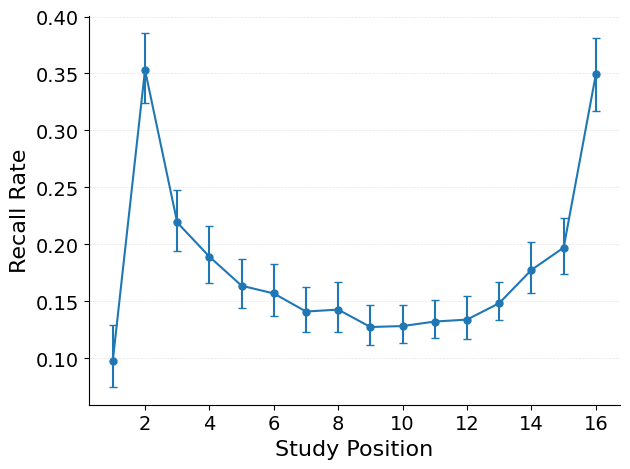

In [4]:
plot_relative_srac(datasets=data, trial_masks=trial_mask, size=size, confidence_level=confidence_level)
if ylim is not None:
    for ax in plt.gcf().axes:
        ax.set_ylim(ylim)
save_figure(figure_dir, figure_str)

## Interpretation

The x-axis shows output position and the y-axis shows the probability that the recall at that position immediately follows its study predecessor. Key patterns:

- **High values**: participants frequently maintain local study order in their recall sequence.
- **Declining across output positions**: local order preservation weakens as the recall sequence progresses.

## API Details

### Notebook parameters

- `data_path` — path to an HDF5 file containing a `RecallDataset`.
- `figure_dir` — directory for saving figures.
- `figure_str` — base filename for the saved figure. Leave empty to display without saving.
- `ylim` — y-axis limits as a tuple, or `None` for automatic scaling.
- `trial_query` — a Python expression evaluated against the dataset to select trials.
- `size` — maximum number of study positions a single item can occupy.
- `confidence_level` — confidence level for subject-wise error bars.
